In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load processed data
daily_sentiment = pd.read_csv('../data/processed/daily_sentiment.csv')
returns = pd.read_csv('../data/processed/returns.csv', index_col=0)

# Parse dates
daily_sentiment['date_only'] = pd.to_datetime(daily_sentiment['date_only'])
returns.index = pd.to_datetime(returns.index)

print(f"Sentiment: {daily_sentiment.shape}")
print(f"Returns: {returns.shape}")
print(f"\nReturns columns: {returns.columns.tolist()}")

Sentiment: (1062, 5)
Returns: (1047, 10)

Returns columns: ['AIR.PA', 'BA', 'BA.L', 'GD', 'HO.PA', 'LMT', 'NOC', 'RHM.DE', 'RTX', 'SAF.PA']


In [3]:
# Rename date column for merge
daily_sentiment = daily_sentiment.rename(columns={'date_only': 'date'})
returns_reset = returns.reset_index().rename(columns={'Date': 'date', 'index': 'date'})
returns_reset['date'] = pd.to_datetime(returns_reset['date'])

# Merge on date
merged = pd.merge(daily_sentiment, returns_reset, on='date', how='inner')

print(f"Merged shape: {merged.shape}")
print(f"Date range: {merged['date'].min()} to {merged['date'].max()}")
merged.head()

Merged shape: (768, 15)
Date range: 2017-01-24 00:00:00 to 2021-01-05 00:00:00


,date,sentiment_mean,sentiment_min,sentiment_max,tweet_count,AIR.PA,BA,BA.L,GD,HO.PA,LMT,NOC,RHM.DE,RTX,SAF.PA
0,2017-01-24,0.000000,0.0000,0.0000,1,0.001681,0.017169,-0.003333,0.000113,-0.003376,-0.017749,0.003884,0.014746,0.011510,-0.009614
1,2017-01-27,-0.248100,-0.2481,-0.2481,1,-0.003697,-0.008396,-0.005872,0.044219,0.005637,-0.005765,0.012645,-0.003061,-0.005980,-0.013182
2,2017-01-30,-0.086800,-0.0868,-0.0868,1,-0.021339,-0.012701,-0.012658,-0.014422,-0.014756,-0.002643,-0.001523,-0.003629,-0.004831,-0.012887
3,2017-02-02,-0.149767,-0.2714,0.0000,3,-0.004121,-0.010429,0.001717,-0.003701,0.006933,0.004264,0.004501,-0.013328,0.001664,0.006536
4,2017-02-03,-0.688300,-0.7119,-0.6448,3,0.003501,0.000863,0.000000,0.015303,-0.002709,0.009882,0.006570,-0.007262,0.011905,0.005860


In [4]:
# Add lagged sentiment (tweet effect on next day returns)
merged = merged.sort_values('date')
merged['sentiment_lag1'] = merged['sentiment_mean'].shift(1)
merged['sentiment_lag2'] = merged['sentiment_mean'].shift(2)
merged = merged.dropna()

print(f"Shape after adding lags: {merged.shape}")

Shape after adding lags: (766, 17)


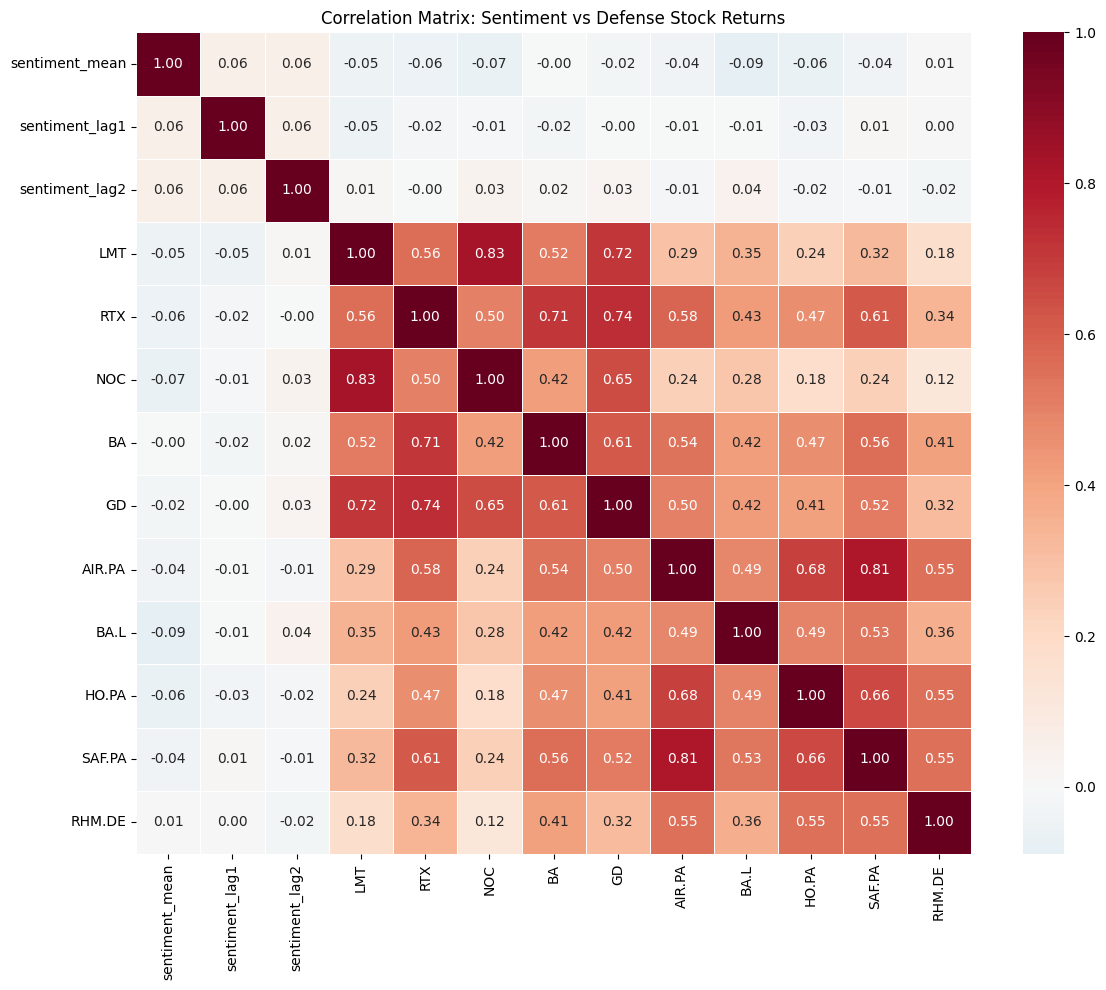

In [5]:
# Select relevant columns
cols = ['sentiment_mean', 'sentiment_lag1', 'sentiment_lag2',
        'LMT', 'RTX', 'NOC', 'BA', 'GD',
        'AIR.PA', 'BA.L', 'HO.PA', 'SAF.PA', 'RHM.DE']

corr_matrix = merged[cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix: Sentiment vs Defense Stock Returns')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

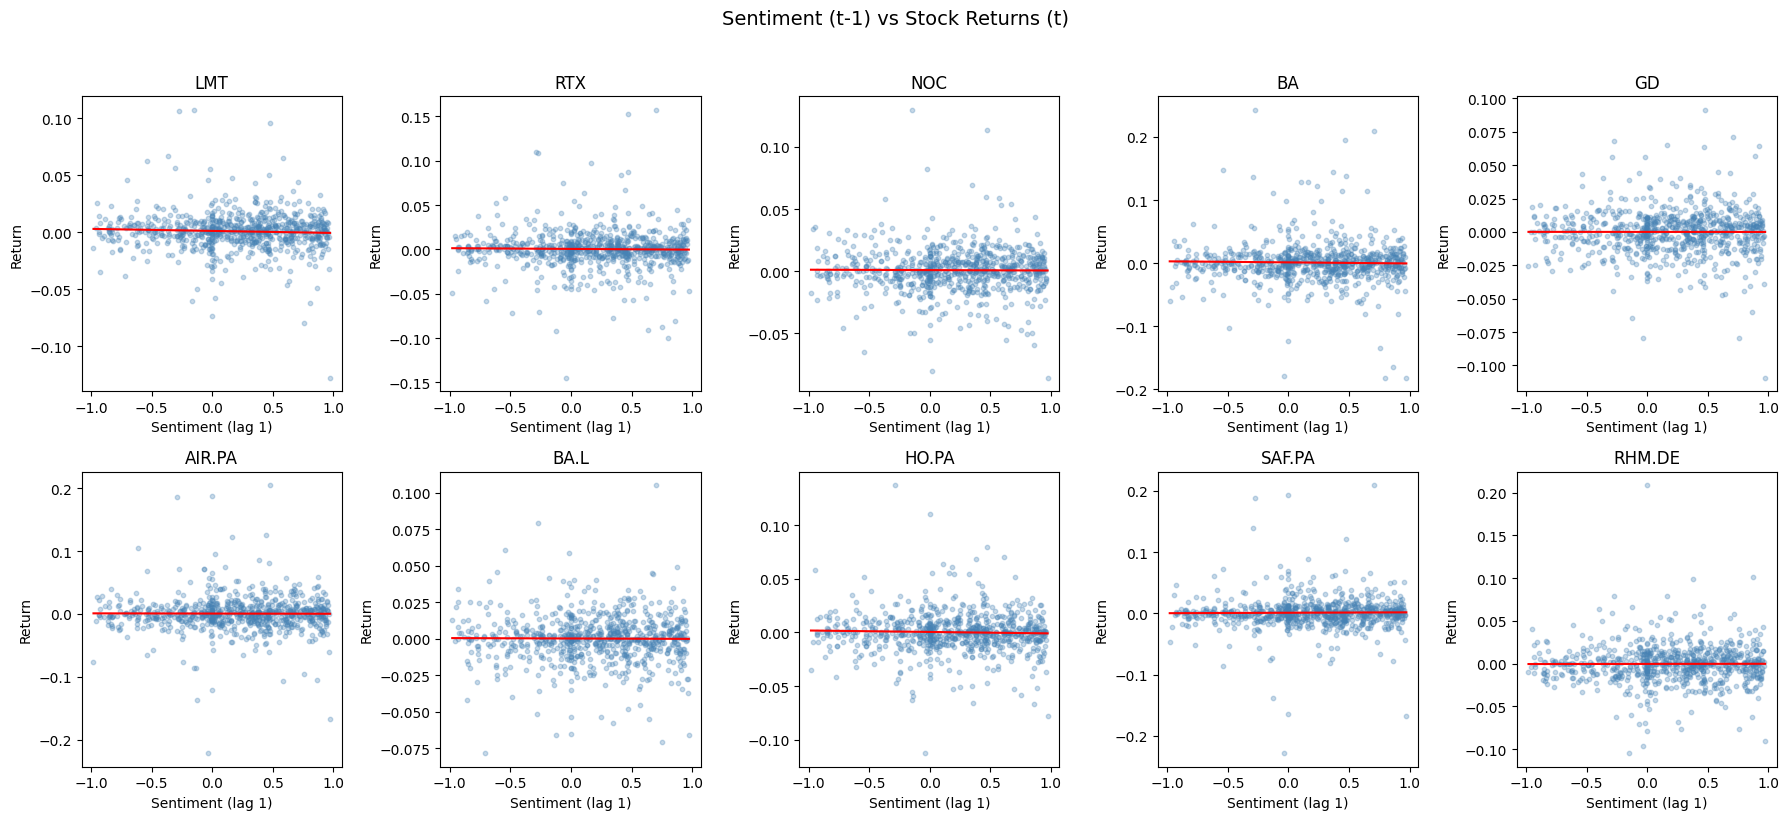

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
tickers = ['LMT', 'RTX', 'NOC', 'BA', 'GD', 'AIR.PA', 'BA.L', 'HO.PA', 'SAF.PA', 'RHM.DE']

for i, ticker in enumerate(tickers):
    row = i // 5
    col = i % 5
    axes[row, col].scatter(merged['sentiment_lag1'], merged[ticker],
                           alpha=0.3, color='steelblue', s=10)
    # Add trend line
    z = np.polyfit(merged['sentiment_lag1'], merged[ticker], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(merged['sentiment_lag1'])
    axes[row, col].plot(x_sorted, p(x_sorted), color='red', linewidth=1.5)
    axes[row, col].set_title(ticker)
    axes[row, col].set_xlabel('Sentiment (lag 1)')
    axes[row, col].set_ylabel('Return')

plt.suptitle('Sentiment (t-1) vs Stock Returns (t)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/scatter_sentiment_returns.png', dpi=150)
plt.show()